 ## Importing Libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
import time
import sys
import struct
import os

from scipy.optimize import curve_fit
import psutil

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = "Arial"

In [2]:
print(psutil.virtual_memory())

svmem(total=34299375616, available=13807747072, percent=59.7, used=20491628544, free=13807747072)


 ## TTTR file reading - Read_PTU

In [2]:
# Read_PTU.py    Read PicoQuant Unified TTTR Files
# This is demo code. Use at your own risk. No warranties.
# Keno Goertz, PicoQUant GmbH, February 2018

# Note that marker events have a lower time resolution and may therefore appear
# in the file slightly out of order with respect to regular (photon) event records.
# This is by design. Markers are designed only for relatively coarse
# synchronization requirements such as image scanning.

# T Mode data are written to an output file [filename]
# We do not keep it in memory because of the huge amout of memory
# this would take in case of large files. Of course you can change this,
# e.g. if your files are not too big.
# Otherwise it is best process the data on the fly and keep only the results.

import time
import sys
import struct
import io

# Tag Types
tyEmpty8 = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8 = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8 = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64 = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8 = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8 = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

# Record types
rtPicoHarpT3 = struct.unpack(">i", bytes.fromhex('00010303'))[0]
rtPicoHarpT2 = struct.unpack(">i", bytes.fromhex('00010203'))[0]
rtHydraHarpT3 = struct.unpack(">i", bytes.fromhex('00010304'))[0]
rtHydraHarpT2 = struct.unpack(">i", bytes.fromhex('00010204'))[0]
rtHydraHarp2T3 = struct.unpack(">i", bytes.fromhex('01010304'))[0]
rtHydraHarp2T2 = struct.unpack(">i", bytes.fromhex('01010204'))[0]
rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
rtMultiHarpT3 = struct.unpack(">i", bytes.fromhex('00010307'))[0]
rtMultiHarpT2 = struct.unpack(">i", bytes.fromhex('00010207'))[0]

# global variables
global inputfile
global outputfile
global recNum
global oflcorrection
global truensync
global dlen
global isT2
global globRes
global numRecords

sys.argv[1] = r'G:\Shared drives\Pauzauskie Team Drive\Users\CG\Lab Work\TB-TCSPC\05172023\default-1_000.ptu'
sys.argv[2] = r'G:\Shared drives\Pauzauskie Team Drive\Users\CG\Lab Work\TB-TCSPC\05172023\default-1_000.out'

if len(sys.argv) != 3:
    print("USAGE: Read_PTU.py inputfile.PTU outputfile.out")
    exit(0)

inputfile = open(sys.argv[1], "rb")
# The following is needed for support of wide strings
outputfile = io.open(sys.argv[2], "w+", encoding="utf-16le")

# Check if inputfile is a valid PTU file
# Python strings don't have terminating NULL characters, so they're stripped
magic = inputfile.read(8).decode("utf-8").strip('\0')
if magic != "PQTTTR":
    print("ERROR: Magic invalid, this is not a PTU file.")
    inputfile.close()
    outputfile.close()
    exit(0)

version = inputfile.read(8).decode("utf-8").strip('\0')
outputfile.write("Tag version: %s\n" % version)

# Write the header data to outputfile and also save it in memory.
# There's no do ... while in Python, so an if statement inside the while loop
# breaks out of it
tagDataList = []  # Contains tuples of (tagName, tagValue)

while True:
    tagIdent = inputfile.read(32).decode("utf-8").strip('\0')
    tagIdx = struct.unpack("<i", inputfile.read(4))[0]
    tagTyp = struct.unpack("<i", inputfile.read(4))[0]
    if tagIdx > -1:
        evalName = tagIdent + '(' + str(tagIdx) + ')'
    else:
        evalName = tagIdent
    outputfile.write("\n%-40s" % evalName)
    if tagTyp == tyEmpty8:
        inputfile.read(8)
        outputfile.write("<empty Tag>")
        tagDataList.append((evalName, "<empty Tag>"))
    elif tagTyp == tyBool8:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        if tagInt == 0:
            outputfile.write("False")
            tagDataList.append((evalName, "False"))
        else:
            outputfile.write("True")
            tagDataList.append((evalName, "True"))
    elif tagTyp == tyInt8:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("%d" % tagInt)
        tagDataList.append((evalName, tagInt))
    elif tagTyp == tyBitSet64:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("{0:#0{1}x}".format(tagInt, 18))
        tagDataList.append((evalName, tagInt))
    elif tagTyp == tyColor8:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("{0:#0{1}x}".format(tagInt, 18))
        tagDataList.append((evalName, tagInt))
    elif tagTyp == tyFloat8:
        tagFloat = struct.unpack("<d", inputfile.read(8))[0]
        outputfile.write("%-3E" % tagFloat)
        tagDataList.append((evalName, tagFloat))
    elif tagTyp == tyFloat8Array:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("<Float array with %d entries>" % tagInt / 8)
        tagDataList.append((evalName, tagInt))
    elif tagTyp == tyTDateTime:
        tagFloat = struct.unpack("<d", inputfile.read(8))[0]
        tagTime = int((tagFloat - 25569) * 86400)
        tagTime = time.gmtime(tagTime)
        outputfile.write(time.strftime("%a %b %d %H:%M:%S %Y", tagTime))
        tagDataList.append((evalName, tagTime))
    elif tagTyp == tyAnsiString:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        tagString = inputfile.read(tagInt).decode("utf-8").strip("\0")
        outputfile.write("%s" % tagString)
        tagDataList.append((evalName, tagString))
    elif tagTyp == tyWideString:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        tagString = inputfile.read(tagInt).decode("utf-16le",
                                                  errors="ignore").strip("\0")
        outputfile.write(tagString)
        tagDataList.append((evalName, tagString))
    elif tagTyp == tyBinaryBlob:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("<Binary blob with %d bytes>" % tagInt)
        tagDataList.append((evalName, tagInt))
    else:
        print("ERROR: Unknown tag type")
        exit(0)
    if tagIdent == "Header_End":
        break

# Reformat the saved data for easier access
tagNames = [tagDataList[i][0] for i in range(0, len(tagDataList))]
tagValues = [tagDataList[i][1] for i in range(0, len(tagDataList))]

# get important variables from headers
numRecords = tagValues[tagNames.index("TTResult_NumberOfRecords")]
globRes = tagValues[tagNames.index("MeasDesc_GlobalResolution")]
print("Writing %d records, this may take a while..." % numRecords)


def gotOverflow(count):
    global outputfile, recNum
    outputfile.write("%u OFL * %2x\n" % (recNum, count))


def gotMarker(timeTag, markers):
    global outputfile, recNum
    outputfile.write("%u MAR %2x %u\n" % (recNum, markers, timeTag))


def gotPhoton(timeTag, channel, dtime):
    global outputfile, isT2, recNum
    if isT2:
        outputfile.write("%u CHN %1x %u %8.0lf\n" % (recNum, channel, timeTag,\
                         (timeTag * globRes * 1e12)))
    else:
        outputfile.write("%u CHN %1x %u %8.0lf %10u\n" % (recNum, channel,\
                         timeTag, (timeTag * globRes * 1e9), dtime))


def readPT3():
    global inputfile, outputfile, recNum, oflcorrection, dlen, numRecords
    T3WRAPAROUND = 65536
    for recNum in range(0, numRecords):
        # The data is stored in 32 bits that need to be divided into smaller
        # groups of bits, with each group of bits representing a different
        # variable. In this case, channel, dtime and nsync. This can easily be
        # achieved by converting the 32 bits to a string, dividing the groups
        # with simple array slicing, and then converting back into the integers.
        try:
            recordData = "{0:0{1}b}".format(
                struct.unpack("<I", inputfile.read(4))[0], 32)
        except:
            print("The file ended earlier than expected, at record %d/%d."\
                  % (recNum, numRecords))
            exit(0)

        channel = int(recordData[0:4], base=2)
        dtime = int(recordData[4:16], base=2)
        nsync = int(recordData[16:32], base=2)
        if channel == 0xF:  # Special record
            if dtime == 0:  # Not a marker, so overflow
                # gotOverflow(1)
                oflcorrection += T3WRAPAROUND
            else:
                truensync = oflcorrection + nsync
                # gotMarker(truensync, dtime)
        else:
            if channel == 0 or channel > 4:  # Should not occur
                print("Illegal Channel: #%1d %1u" % (dlen, channel))
                outputfile.write("\nIllegal channel ")
            truensync = oflcorrection + nsync
            # gotPhoton(truensync, channel, dtime)
            dlen += 1
        if recNum % 100000 == 0:
            sys.stdout.write("\rProgress: %.1f%%" %
                             (float(recNum) * 100 / float(numRecords)))
            sys.stdout.flush()


def readPT2():
    global inputfile, outputfile, recNum, oflcorrection, numRecords
    T2WRAPAROUND = 210698240
    for recNum in range(0, numRecords):
        try:
            recordData = "{0:0{1}b}".format(
                struct.unpack("<I", inputfile.read(4))[0], 32)
        except:
            print("The file ended earlier than expected, at record %d/%d."\
                  % (recNum, numRecords))
            exit(0)

        channel = int(recordData[0:4], base=2)
        time = int(recordData[4:32], base=2)
        if channel == 0xF:  # Special record
            # lower 4 bits of time are marker bits
            markers = int(recordData[28:32], base=2)
            if markers == 0:  # Not a marker, so overflow
                # gotOverflow(1)
                oflcorrection += T2WRAPAROUND
            else:
                # Actually, the lower 4 bits for the time aren't valid because
                # they belong to the marker. But the error caused by them is
                # so small that we can just ignore it.
                truetime = oflcorrection + time
                # gotMarker(truetime, markers)
        else:
            if channel > 4:  # Should not occur
                print("Illegal Channel: #%1d %1u" % (recNum, channel))
                outputfile.write("\nIllegal channel ")
            truetime = oflcorrection + time
            # gotPhoton(truetime, channel, time)
        if recNum % 100000 == 0:
            sys.stdout.write("\rProgress: %.1f%%" %
                             (float(recNum) * 100 / float(numRecords)))
            sys.stdout.flush()


def readHT3(version):
    global inputfile, outputfile, recNum, oflcorrection, numRecords
    T3WRAPAROUND = 1024
    for recNum in range(0, numRecords):
        try:
            recordData = "{0:0{1}b}".format(
                struct.unpack("<I", inputfile.read(4))[0], 32)
        except:
            print("The file ended earlier than expected, at record %d/%d."\
                  % (recNum, numRecords))
            exit(0)

        special = int(recordData[0:1], base=2)
        channel = int(recordData[1:7], base=2)
        dtime = int(recordData[7:22], base=2)
        nsync = int(recordData[22:32], base=2)
        if special == 1:
            if channel == 0x3F:  # Overflow
                # Number of overflows in nsync. If 0 or old version, it's an
                # old style single overflow
                if nsync == 0 or version == 1:
                    oflcorrection += T3WRAPAROUND
                    # gotOverflow(1)
                else:
                    oflcorrection += T3WRAPAROUND * nsync
                    # gotOverflow(nsync)
            if channel >= 1 and channel <= 15:  # markers
                truensync = oflcorrection + nsync
                # gotMarker(truensync, channel)
        else:  # regular input channel
            truensync = oflcorrection + nsync
            # gotPhoton(truensync, channel, dtime)
        if recNum % 100000 == 0:
            sys.stdout.write("\rProgress: %.1f%%" %
                             (float(recNum) * 100 / float(numRecords)))
            sys.stdout.flush()


def readHT2(version):
    global inputfile, outputfile, recNum, oflcorrection, numRecords
    T2WRAPAROUND_V1 = 33552000
    T2WRAPAROUND_V2 = 33554432
    for recNum in range(0, numRecords):
        try:
            recordData = "{0:0{1}b}".format(
                struct.unpack("<I", inputfile.read(4))[0], 32)
        except:
            print("The file ended earlier than expected, at record %d/%d."\
                  % (recNum, numRecords))
            exit(0)

        special = int(recordData[0:1], base=2)
        channel = int(recordData[1:7], base=2)
        timetag = int(recordData[7:32], base=2)
        if special == 1:
            if channel == 0x3F:  # Overflow
                # Number of overflows in nsync. If old version, it's an
                # old style single overflow
                if version == 1:
                    oflcorrection += T2WRAPAROUND_V1
                    # gotOverflow(1)
                else:
                    if timetag == 0:  # old style overflow, shouldn't happen
                        oflcorrection += T2WRAPAROUND_V2
                        gotOverflow(1)
                    else:
                        oflcorrection += T2WRAPAROUND_V2 * timetag
                        # gotOverflow(timetag)
            if channel >= 1 and channel <= 15:  # markers
                truetime = oflcorrection + timetag
                # gotMarker(truetime, channel)
            if channel == 0:  # sync
                truetime = oflcorrection + timetag
                # gotPhoton(truetime, 0, 0)
        else:  # regular input channel
            truetime = oflcorrection + timetag
            # gotPhoton(truetime, channel + 1, 0)
        if recNum % 100000 == 0:
            sys.stdout.write("\rProgress: %.1f%%" %
                             (float(recNum) * 100 / float(numRecords)))
            sys.stdout.flush()


oflcorrection = 0
dlen = 0
outputfile.write("\n-----------------------\n")
recordType = tagValues[tagNames.index("TTResultFormat_TTTRRecType")]
if recordType == rtPicoHarpT2:
    isT2 = True
    print("PicoHarp T2 data")
    outputfile.write("PicoHarp T2 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ps\n")
    readPT2()
elif recordType == rtPicoHarpT3:
    isT2 = False
    print("PicoHarp T3 data")
    outputfile.write("PicoHarp T3 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ns dtime\n")
    readPT3()
elif recordType == rtHydraHarpT2:
    isT2 = True
    print("HydraHarp V1 T2 data")
    outputfile.write("HydraHarp V1 T2 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ps\n")
    readHT2(1)
elif recordType == rtHydraHarpT3:
    isT2 = False
    print("HydraHarp V1 T3 data")
    outputfile.write("HydraHarp V1 T3 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ns dtime\n")
    readHT3(1)
elif recordType == rtHydraHarp2T2:
    isT2 = True
    print("HydraHarp V2 T2 data")
    outputfile.write("HydraHarp V2 T2 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ps\n")
    readHT2(2)
elif recordType == rtHydraHarp2T3:
    isT2 = False
    print("HydraHarp V2 T3 data")
    outputfile.write("HydraHarp V2 T3 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ns dtime\n")
    readHT3(2)
elif recordType == rtTimeHarp260NT3:
    isT2 = False
    print("TimeHarp260N T3 data")
    outputfile.write("TimeHarp260N T3 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ns dtime\n")
    readHT3(2)
elif recordType == rtTimeHarp260NT2:
    isT2 = True
    print("TimeHarp260N T2 data")
    outputfile.write("TimeHarp260N T2 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ps\n")
    readHT2(2)
elif recordType == rtTimeHarp260PT3:
    isT2 = False
    print("TimeHarp260P T3 data")
    outputfile.write("TimeHarp260P T3 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ns dtime\n")
    readHT3(2)
elif recordType == rtTimeHarp260PT2:
    isT2 = True
    print("TimeHarp260P T2 data")
    outputfile.write("TimeHarp260P T2 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ps\n")
    readHT2(2)
elif recordType == rtMultiHarpT3:
    isT2 = False
    print("MultiHarp T3 data")
    outputfile.write("MultiHarp T3 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ns dtime\n")
    readHT3(2)
elif recordType == rtMultiHarpT2:
    isT2 = True
    print("MultiHarp T2 data")
    outputfile.write("MultiHarp T2 data\n")
    outputfile.write("\nrecord# chan   nsync truetime/ps\n")
    readHT2(2)
else:
    print("ERROR: Unknown record type")
    exit(0)

inputfile.close()
outputfile.close()

USAGE: Read_PTU.py inputfile.PTU outputfile.out
Writing 297519 records, this may take a while...
MultiHarp T2 data
Progress: 67.2%

: 

 ## Histogram file reading - Read_PHU

In [3]:
%matplotlib widget

In [4]:
%load_ext memory_profiler

# Read_PHU.py    Read PicoQuant Unified Histogram Files
# This is demo code. Use at your own risk. No warranties.
# Keno Goertz, PicoQUant GmbH, February 2018

# Note that marker events have a lower time resolution and may therefore appear 
# in the file slightly out of order with respect to regular (photon) event records.
# This is by design. Markers are designed only for relatively coarse 
# synchronization requirements such as image scanning. 

# T Mode data are written to an output file [filename]
# We do not keep it in memory because of the huge amout of memory
# this would take in case of large files. Of course you can change this, 
# e.g. if your files are not too big. 
# Otherwise it is best process the data on the fly and keep only the results.

# Tag Types
tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]


sys.argv[1] = r"G:\Shared drives\Pauzauskie Team Drive\Users\CG\Lab Work\TB-TCSPC\Untitled.phu"
sys.argv[2] = r"G:\Shared drives\Pauzauskie Team Drive\Users\CG\Lab Work\TB-TCSPC\Untitled.txt"

# data_file_1 = r'E:\Shared drives\Pauzauskie Team Drive\CG\Projects\MNVH\Lifetime Data\5 min scan H3 Bulk Diamond 470 nm Pulsed Laser with 500LP filter 1-1.txt'
# data_file_2 = r'E:\Shared drives\Pauzauskie Team Drive\CG\Projects\MNVH\Lifetime Data\5 min scan H3 Bulk Diamond 470 nm Pulsed Laser with 500LP filter 1-2.txt'

head_i, tail_i = os.path.split(sys.argv[1])
head_o, tail_o = os.path.split(sys.argv[2])
# head_d1, tail_d1 = os.path.split(data_file_1)
# head_d2, tail_d2 = os.path.split(data_file_2)

if len(sys.argv) != 3:
    print("USAGE: Read_PHU.py inputfile.PHU outputfile.txt")
    exit(0)

inputfile = open(sys.argv[1], "rb")
outputfile = open(sys.argv[2], "w+")
# outputfile1 = open(data_file_1,"w+")
# outputfile2 = open(data_file_2,"w+")

# Check if inputfile is a valid PHU file
# Python strings don't have terminating NULL characters, so they're stripped
magic = inputfile.read(8).decode("ascii").strip('\0')
if magic != "PQHISTO":
    print("ERROR: Magic invalid, this is not a PHU file.")
    exit(0)

version = inputfile.read(8).decode("ascii").strip('\0')
outputfile.write("Tag version: %s\n" % version)

# Write the header data to outputfile and also save it in memory.
# There's no do ... while in Python, so an if statement inside the while loop
# breaks out of it
tagDataList = []    # Contains tuples of (tagName, tagValue)
while True:
    tagIdent = inputfile.read(32).decode("ascii").strip('\0')
    tagIdx = struct.unpack("<i", inputfile.read(4))[0]
    tagTyp = struct.unpack("<i", inputfile.read(4))[0]
    if tagIdx > -1:
        evalName = tagIdent + '(' + str(tagIdx) + ')'
    else:
        evalName = tagIdent
    outputfile.write("\n%-40s" % evalName)
    if tagTyp == tyEmpty8:
        inputfile.read(8)
        outputfile.write("<empty Tag>")
        tagDataList.append((evalName, "<empty Tag>"))
    elif tagTyp == tyBool8:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        if tagInt == 0:
            outputfile.write("False")
            tagDataList.append((evalName, "False"))
        else:
            outputfile.write("True")
            tagDataList.append((evalName, "True"))
    elif tagTyp == tyInt8:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("%d" % tagInt)
        tagDataList.append((evalName, tagInt))
    elif tagTyp == tyBitSet64:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("{0:#0{1}x}".format(tagInt,18)) # hex with trailing 0s
        tagDataList.append((evalName, tagInt))
    elif tagTyp == tyColor8:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("{0:#0{1}x}".format(tagInt,18)) # hex with trailing 0s
        tagDataList.append((evalName, tagInt))
    elif tagTyp == tyFloat8:
        tagFloat = struct.unpack("<d", inputfile.read(8))[0]
        outputfile.write("%-3E" % tagFloat)
        tagDataList.append((evalName, tagFloat))
    elif tagTyp == tyFloat8Array:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("<Float array with %d entries>" % tagInt/8)
        tagDataList.append((evalName, tagInt))
    elif tagTyp == tyTDateTime:
        tagFloat = struct.unpack("<d", inputfile.read(8))[0]
        tagTime = int((tagFloat - 25569) * 86400)
        tagTime = time.gmtime(tagTime)
        outputfile.write(time.strftime("%a %b %d %H:%M:%S %Y", tagTime))
        tagDataList.append((evalName, tagTime))
    elif tagTyp == tyAnsiString:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        tagString = inputfile.read(tagInt).decode("ascii").strip("\0")
        outputfile.write("%s" % tagString)
        tagDataList.append((evalName, tagString))
    elif tagTyp == tyWideString:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        tagString = inputfile.read(tagInt).decode("ascii").strip("\0")
        outputfile.write("%s" % tagString)
        tagDataList.append((evalName, tagString))
    elif tagTyp == tyBinaryBlob:
        tagInt = struct.unpack("<q", inputfile.read(8))[0]
        outputfile.write("<Binary blob with %d bytes>" % tagInt)
        tagDataList.append((evalName, tagInt))
    else:
        print("ERROR: Unknown tag type")
        exit(0)
    if tagIdent == "Header_End":
        break

# Reformat the saved data for easier access
tagNames = [tagDataList[i][0] for i in range(0, len(tagDataList))]
tagValues = [tagDataList[i][1] for i in range(0, len(tagDataList))]

# Write histogram data to file
curveIndices = [tagValues[i] for i in range(0, len(tagNames))\
                if tagNames[i][0:-3] == "HistResDscr_CurveIndex"]

histogramBins = tagValues[tagNames.index("HistResDscr_HistogramBins(3)")]
y_data = np.zeros(shape=(len(curveIndices),histogramBins))


for i in curveIndices:
    outputfile.write("\n-----------------------")
    histogramBins = tagValues[tagNames.index("HistResDscr_HistogramBins(%d)" % i)]
    resolution = tagValues[tagNames.index("HistResDscr_MDescResolution(%d)" % i)]
    outputfile.write("\nCurve#  %d" % i)
    outputfile.write("\nnBins:  %d" % histogramBins)
    outputfile.write("\nResol:  %3E" % resolution)
    outputfile.write("\nCounts:")
    
    print(resolution)
    y_data_i = []
    x_data = []
    
    # for j in tqdm(range(0, histogramBins)):
    #     try:
    #         histogramData = struct.unpack("<i", inputfile.read(4))[0]
    #         # y_data_i = np.append(y_data_i,histogramData)
    #         x_data = np.append(x_data,j*100)
            
    #     except:
    #         print("The file ended earlier than expected, at bin %d/%d."\
    #               % (j, histogramBins))
    
    # # y_data[i,:] = y_data_i
    #     #if j>28 and j<1600:
    #         #if i==0:
    #             #outputfile1.write("%0.4f %d\n" %(j*100,histogramData))
    #         #if i==1:
    #             #outputfile2.write("%0.4f %d\n" %(j*100,histogramData))
        
        
    #print(y_data)

    
    #print(np.argmin(np.abs(x_data[:]-280)))

    #print(np.argmin(np.abs(x_data[:]-16000)))
    
inputfile.close()
outputfile.close()
# outputfile1.close()

USAGE: Read_PHU.py inputfile.PHU outputfile.txt
4.096e-08


100%|██████████| 65536/65536 [00:00<00:00, 69942.70it/s] 


ValueError: could not broadcast input array from shape (0,) into shape (65536,)

: 

In [ ]:
## Exponential decay function

def exp_decay(t,a,tau):
    return a*np.exp(-t/tau)

In [10]:
## Bi-exponential decay function

def bi_exp_decay(t,a1,tau_1,a2,tau_2,t0,c):
    return a1*np.exp(-(t-t0)/tau_1)+a2*np.exp(-(t-t0)/tau_2) + c
    #return exp_decay(t,a1,tau_1) + exp_decay(t,a2,tau_2) + c

In [11]:
print(np.shape(x_data))
print(np.shape(y_data))

time_x = x_data*resolution*10000000

#plt.plot(x_data[np.argmin(np.abs(x_data[:]-280)):np.argmin(np.abs(x_data[:]-16000))],y_data[np.argmin(np.abs(x_data[:]-280)):np.argmin(np.abs(x_data[:]-16000))],label="Curve#  %d" % i)

start = np.argmin(np.abs(time_x[:]-0))
stop = np.argmin(np.abs(time_x[:]-120))

print(start,stop)

time_x_edit = time_x[start:stop]

#intes_y = np.zeros(shape=(len(curveIndices),stop-start))
intes_y = []


plt.figure(figsize=(10,5))
plt.subplot(111)

for i in range(0,1):
    intes_y = y_data[i,start:stop]
    decay_start = np.argmax(intes_y)
    decay_stop = stop
    
    time_decay = time_x_edit[decay_start:decay_stop]
    decay_curve = intes_y[decay_start:decay_stop]
    
    #norm_decay_curve = (decay_curve-np.min(decay_curve))/(np.max(decay_curve)-np.min(decay_curve))
    #print(norm_decay_curve)
    
    #a1 = 0.3
    #tau_1 = 3
    
    #a2 = 0.7
    #tau_2 = 10
    
    #t0 = -0.0218
    #c = 0.0139
    
    #p0 = (a1,tau_1,a2,tau_2,t0,c)
    
    popt, pcov = curve_fit(bi_exp_decay,time_decay,decay_curve)
    
    print(popt)
    
    #residuals = norm_decay_curve - bi_exp_decay(time_decay,*popt)
    #ss_res = np.sum(residuals**2)
    #ss_tot = np.sum((norm_decay_curve-np.mean(norm_decay_curve))**2)
    #r_squared = 1 - (ss_res / ss_tot)

    #print(r_squared)
    #plt.plot(time_x_edit,norm_intes_y,label='Curve %d'%(i+1))
    #plt.plot(time_x_edit,intes_y,label='Curve %d'%(i+1))
    
    plt.plot(time_decay,decay_curve,label='Curve %d'%(i+1))
    plt.plot(time_decay,bi_exp_decay(time_decay,*popt),label='Fit %d'%(i+1))
    
plt.xlabel('Time(ns)',fontsize=12.0)
plt.ylabel('Counts',fontsize=12.0)

plt.yscale('log')
#plt.title('Data from Multiharp Software' + tail_i,fontsize=15.0)
#plt.xlim(0,120)
    
plt.legend(title='Curves')
plt.show()

(65536,)
(4, 65536)
0 1500


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

[-5.18441014e-03  8.26163546e+00  5.26673917e-03  8.26166321e+00
  1.68071356e+02  8.41920111e+02]


65536


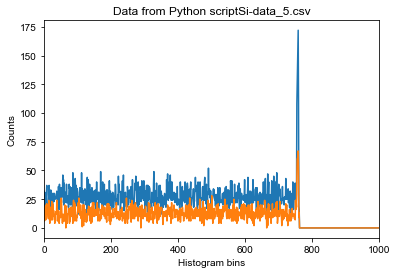

In [7]:
data_file = r"E:\Shared drives\Pauzauskie Team Drive\CG\Training\TB-TCSPC\Si-data_5.csv"

head_data, tail_data = os.path.split(data_file)

data = pd.read_csv(data_file, sep=None, skiprows=6, engine='python', names=['c1','c2','c3','c4','c5'])
#print(data)

n2 = data['c2'].to_numpy()
n3 = data['c3'].to_numpy()
n4 = data['c4'].to_numpy()
n5 = data['c5'].to_numpy()
#n1 = data['c1'].to_numpy()
print(len(n2))

plt.plot(n2)
plt.plot(n3)
plt.xlim(0,1000)
plt.title('Data from Python script' + tail_data)
plt.xlabel('Histogram bins')
plt.ylabel('Counts')
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Thu Jul  1 09:46:35 2021

@author: Donut
"""

# Demo for access to MultiHarp 150 Hardware via MHLIB.DLL v2.0.
# The program performs a measurement based on hard coded settings.
# The resulting histogram (65536 channels) is stored in an ASCII output file.
#
# Keno Goertz, PicoQuant GmbH, July 2019
# Michael Wahl, PicoQuant GmbH, May 2020

import time
import ctypes as ct
from ctypes import byref
import os
import sys
import time

if sys.version_info[0] < 3:
    print("[Warning] Python 2 is not fully supported. It might work, but "
          "use Python 3 if you encounter errors.\n")
    raw_input("press RETURN to continue"); print
    input = raw_input

# From mhdefin.h
LIB_VERSION = "2.0"
MAXDEVNUM = 8
MODE_HIST = 0
MAXLENCODE = 6
MAXINPCHAN = 16
MAXHISTLEN = 65536
FLAG_OVERFLOW = 0x0001

# Measurement parameters, these are hardcoded since this is just a demo
binning = 17 # you can change this
offset = 0
tacq = 10000 # Measurement time in millisec, you can change this
syncDivider = 1 # you can change this 
syncEdgeTrg = 0 # you can change this (in mV)
syncChannelOffset = 0 # you can change this (in ps, like a cable delay)
inputEdgeTrg = -50 # you can change this (in mV)
inputChannelOffset = 0 # you can change this (in ps, like a cable delay)
cmd = 0

# Variables to store information read from DLLs
counts = [(ct.c_uint * MAXHISTLEN)() for i in range(0, MAXINPCHAN)]
dev = []
libVersion = ct.create_string_buffer(b"", 8)
hwSerial = ct.create_string_buffer(b"", 8)
hwPartno = ct.create_string_buffer(b"", 8)
hwVersion = ct.create_string_buffer(b"", 8)
hwModel = ct.create_string_buffer(b"", 24)
errorString = ct.create_string_buffer(b"", 40)
numChannels = ct.c_int()
histLen = ct.c_int()
resolution = ct.c_double()
syncRate = ct.c_int()
countRate = ct.c_int()
flags = ct.c_int()
warnings = ct.c_int()
warningstext = ct.create_string_buffer(b"", 16384)

if os.name == "nt":
    mhlib = ct.WinDLL("mhlib64.dll")
else:
    mhlib = ct.CDLL("libmh150.so")

def closeDevices():
    for i in range(0, MAXDEVNUM):
        mhlib.MH_CloseDevice(ct.c_int(i))
    exit(0)

def tryfunc(retcode, funcName):
    if retcode < 0:
        mhlib.MH_GetErrorString(errorString, ct.c_int(retcode))
        print("MH_%s error %d (%s). Aborted." % (funcName, retcode,
              errorString.value.decode("utf-8")))
        closeDevices()

mhlib.MH_GetLibraryVersion(libVersion)
print("Library version is %s" % libVersion.value.decode("utf-8"))
if libVersion.value.decode("utf-8") != LIB_VERSION:
    print("Warning: The application was built for version %s" % LIB_VERSION)

outputfile = open("histomode.out", "w+")

outputfile.write("Binning         : %d\n" % binning)
outputfile.write("Offset          : %d\n" % offset)
outputfile.write("AcquisitionTime : %d\n" % tacq)
outputfile.write("SyncDivider     : %d\n" % syncDivider)
outputfile.write("SyncEdgeTrg     : %d\n" % syncEdgeTrg)
outputfile.write("InputEdgeTrg    : %d\n" % inputEdgeTrg)

print("\nSearching for MultiHarp devices...")
print("Devidx     Status")

for i in range(0, MAXDEVNUM):
    retcode = mhlib.MH_OpenDevice(ct.c_int(i), hwSerial)
    if retcode == 0:
        print("  %1d        S/N %s" % (i, hwSerial.value.decode("utf-8")))
        dev.append(i)
    else:
        if retcode == -1: # MH_ERROR_DEVICE_OPEN_FAIL
            print("  %1d        no device" % i)
        else:
            mhlib.MH_GetErrorString(errorString, ct.c_int(retcode))
            print("  %1d        %s" % (i, errorString.value.decode("utf8")))

# In this demo we will use the first MultiHarp device we find, i.e. dev[0].
# You can also use multiple devices in parallel.
# You can also check for specific serial numbers, so that you always know 
# which physical device you are talking to.

if len(dev) < 1:
    print("No device available.")
    exit(0)
print("Using device #%1d" % dev[0])
print("\nInitializing the device...")

# Histo mode with internal clock
tryfunc(mhlib.MH_Initialize(ct.c_int(dev[0]), ct.c_int(MODE_HIST), ct.c_int(0)),
        "Initialize")

# Only for information
tryfunc(mhlib.MH_GetHardwareInfo(dev[0], hwModel, hwPartno, hwVersion),
        "GetHardwareInfo")
print("Found Model %s Part no %s Version %s" % (hwModel.value.decode("utf-8"),
      hwPartno.value.decode("utf-8"), hwVersion.value.decode("utf-8")))

tryfunc(mhlib.MH_GetNumOfInputChannels(ct.c_int(dev[0]), byref(numChannels)),
        "GetNumOfInputChannels")
print("Device has %i input channels." % numChannels.value)

tryfunc(mhlib.MH_SetSyncDiv(ct.c_int(dev[0]), ct.c_int(syncDivider)), "SetSyncDiv")

tryfunc(
    mhlib.MH_SetSyncEdgeTrg(ct.c_int(dev[0]), ct.c_int(syncEdgeTrg),
                            ct.c_int(1)),
    "SetSyncEdgeTrg"
)

tryfunc(mhlib.MH_SetSyncChannelOffset(ct.c_int(dev[0]), ct.c_int(syncChannelOffset)),
        "SetSyncChannelOffset")

# we use the same input settings for all channels, you can change this
for i in range(0, numChannels.value):
    tryfunc(
        mhlib.MH_SetInputEdgeTrg(ct.c_int(dev[0]), ct.c_int(i), ct.c_int(inputEdgeTrg),
                                 ct.c_int(1)),
        "SetInputEdgeTrg"
    )

    tryfunc(
        mhlib.MH_SetInputChannelOffset(ct.c_int(dev[0]), ct.c_int(i),
                                       ct.c_int(inputChannelOffset)),
        "SetInputChannelOffset"
    )

tryfunc(mhlib.MH_SetHistoLen(ct.c_int(dev[0]), ct.c_int(MAXLENCODE), byref(histLen)),
        "SetHistoLen")
print("Histogram length is %d" % histLen.value)

tryfunc(mhlib.MH_SetBinning(ct.c_int(dev[0]), ct.c_int(binning)), "SetBinning")
tryfunc(mhlib.MH_SetOffset(ct.c_int(dev[0]), ct.c_int(offset)), "SetOffset")
tryfunc(mhlib.MH_GetResolution(ct.c_int(dev[0]), byref(resolution)), "GetResolution")
print("Resolution is %1.1lfps" % resolution.value)

# Note: after Init or SetSyncDiv you must allow >100 ms for valid  count rate readings
time.sleep(0.2)

tryfunc(mhlib.MH_GetSyncRate(ct.c_int(dev[0]), byref(syncRate)), "GetSyncRate")
print("\nSyncrate=%1d/s" % syncRate.value)

for i in range(0, numChannels.value):
    tryfunc(mhlib.MH_GetCountRate(ct.c_int(dev[0]), ct.c_int(i), byref(countRate)),
            "GetCountRate")
    print("Countrate[%1d]=%1d/s" % (i, countRate.value))

# After getting the count rates you can check for warnings
tryfunc(mhlib.MH_GetWarnings(ct.c_int(dev[0]), byref(warnings)), "GetWarnings")
if warnings.value != 0:
    mhlib.MH_GetWarningsText(ct.c_int(dev[0]), warningstext, warnings)
    print("\n\n%s" % warningstext.value.decode("utf-8")) 

tryfunc(mhlib.MH_SetStopOverflow(ct.c_int(dev[0]), ct.c_int(0), ct.c_int(10000)),
        "SetStopOverflow") # for example only

while cmd != "q":
    tryfunc(mhlib.MH_ClearHistMem(ct.c_int(dev[0])), "ClearHistMem")

    print("press RETURN to start measurement")
    input()

    tryfunc(mhlib.MH_GetSyncRate(ct.c_int(dev[0]), byref(syncRate)), "GetSyncRate")
    print("Syncrate=%1d/s" % syncRate.value)

    for i in range(0, numChannels.value):
        tryfunc(mhlib.MH_GetCountRate(ct.c_int(dev[0]), ct.c_int(i), byref(countRate)),
                "GetCountRate")
        print("Countrate[%1d]=%1d/s" % (i, countRate.value))

    # here you could check for warnings again
    
    tryfunc(mhlib.MH_StartMeas(ct.c_int(dev[0]), ct.c_int(tacq)), "StartMeas")
    print("\nMeasuring for %1d milliseconds..." % tacq)
    
    ctcstatus = ct.c_int(0)
    while ctcstatus.value == 0:
        tryfunc(mhlib.MH_CTCStatus(ct.c_int(dev[0]), byref(ctcstatus)),
                "CTCStatus")
        
    tryfunc(mhlib.MH_StopMeas(ct.c_int(dev[0])), "StopMeas")
    
    for i in range(0, numChannels.value):
        tryfunc(
            mhlib.MH_GetHistogram(ct.c_int(dev[0]), byref(counts[i]),
                                  ct.c_int(i)),
            "GetHistogram"
        )

        integralCount = 0
        for j in range(0, histLen.value):
            integralCount += counts[i][j]
    
        print("  Integralcount[%1d]=%1.0lf" % (i,integralCount))

    tryfunc(mhlib.MH_GetFlags(ct.c_int(dev[0]), byref(flags)), "GetFlags")
    
    if flags.value & FLAG_OVERFLOW > 0:
        print("  Overflow.")

    print("Enter c to continue or q to quit and save the count data.")
    cmd = input()

for j in range(0, histLen.value):
    for i in range(0, numChannels.value):
        outputfile.write("%5d " % counts[i][j])
    outputfile.write("\n")

closeDevices()
outputfile.close()